#Introdução de Novas Observações no Ajustamento + Efeito na precisão dos parâmetros estimados

Após o ajustamento das observações, caso novas observações sejam coletadas, estas podem ser inseridas sem necessidade de refazer todo o ajustamento.

1) Ajuste a rede abaixo com suas 5 observações, calculando o vetor dos parâmetros estimados $x$ e a matriz covariância dos parâmetros $\Sigma_x$:

Dados:

$h_A=0m$ (injunção fixa).

Desvio padrão de todas as observações é de $10mm$.

Unidade dos desníveis da figura: metro



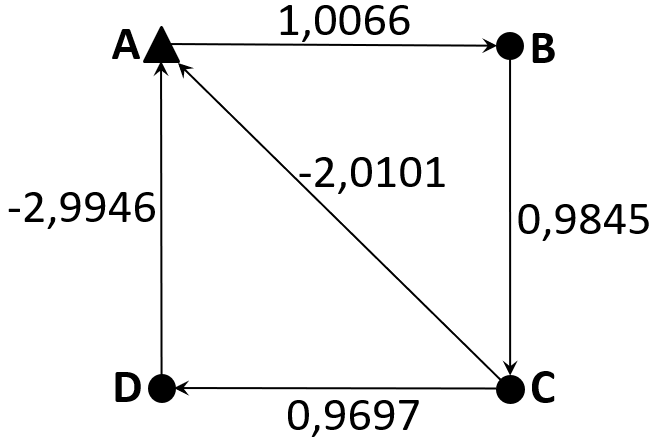

2) Agora, considere que passado um tempo foi coletada uma nova observação de desnível de B para D com valor de 2,0091m e desvio padrão de 10mm. Estimar novamente $x$ e $\Sigma_x$, considerando a modelagem para introdução de novas observações (contida no vídeo da Aula: Introdução ao Ajustamento Recursivo).

3) Calcule os desvios padrão dos parâmetros estimados nos problemas 1) e 2). Em geral, eles aumentam ou diminuem com o aumento da redundância da rede?

obs: por redundância, entendam a abundância de observações em relação à quantidade de parâmetros.

## Solução

In [2]:
import numpy as np

np.set_printoptions(precision=6, suppress=True)

sigma = 0.01  # 10 mm = 0,01 m
h_A = 0.0

# Vetor de incógnitas: x = [h_B, h_C, h_D]^T
# Observações do croqui (em metros):
# 1) A -> B = 1,0066   =>  h_B - h_A = 1,0066
# 2) B -> C = 0,9845   =>  h_C - h_B = 0,9845
# 3) C -> D = 0,9697   =>  h_D - h_C = 0,9697
# 4) D -> A = -2,9946  =>  h_A - h_D = -2,9946
# 5) C -> A = -2,0101  =>  h_A - h_C = -2,0101
A = np.array([
    [ 1,  0,  0],
    [-1,  1,  0],
    [ 0, -1,  1],
    [ 0,  0, -1],
    [ 0, -1,  0],
], dtype=float)

l = np.array([1.0066, 0.9845, 0.9697, -2.9946, -2.0101], dtype=float)


def ajustar(A, l, sigma):
    m = len(l)
    Sigma_l = (sigma ** 2) * np.eye(m)
    P = np.linalg.inv(Sigma_l)

    N = A.T @ P @ A
    U = A.T @ P @ l
    x_hat = np.linalg.solve(N, U)
    v = A @ x_hat - l
    Sigma_x = np.linalg.inv(N)
    sigma_x = np.sqrt(np.diag(Sigma_x))
    sigma0_sq = (v.T @ P @ v) / (m - A.shape[1])

    return {
        'x_hat': x_hat,
        'v': v,
        'Sigma_x': Sigma_x,
        'sigma_x': sigma_x,
        'sigma0_sq': sigma0_sq,
    }


def atualizar_sequencialmente(x_hat, Sigma_x, a_novo, l_novo, sigma_novo):
    a_novo = np.asarray(a_novo, dtype=float).reshape(1, -1)
    l_novo = np.asarray([l_novo], dtype=float)
    Sigma_novo = np.array([[sigma_novo ** 2]], dtype=float)

    K = Sigma_x @ a_novo.T @ np.linalg.inv(a_novo @ Sigma_x @ a_novo.T + Sigma_novo)
    inovacao = l_novo - a_novo @ x_hat

    x_atualizado = x_hat + (K @ inovacao).ravel()
    Sigma_x_atualizada = Sigma_x - K @ a_novo @ Sigma_x

    return x_atualizado, Sigma_x_atualizada, K, inovacao


# Parte 1: ajuste com as 5 observações
res_1 = ajustar(A, l, sigma)
x_1 = res_1['x_hat']
Sigma_x_1 = res_1['Sigma_x']
sigma_x_1 = res_1['sigma_x']

print('PARTE 1 - Ajuste com 5 observações')
print('x_hat = [h_B, h_C, h_D]^T (m)')
print(x_1)
print()
print('Sigma_x (m^2) =')
print(Sigma_x_1)
print()
print('Desvios-padrão dos parâmetros (m) =')
print(sigma_x_1)
print()
print('Resíduos v (m) =')
print(res_1['v'])
print()
print(f'sigma0^2 a posteriori = {res_1["sigma0_sq"]:.6f}')


# Parte 2: introdução sequencial da nova observação B -> D = 2,0091 m
# h_D - h_B = 2,0091  =>  [-1, 0, 1] x = 2,0091
a_novo = np.array([-1, 0, 1], dtype=float)
l_novo = 2.0091

x_2_seq, Sigma_x_2_seq, K, inovacao = atualizar_sequencialmente(
    x_1, Sigma_x_1, a_novo, l_novo, sigma
)
sigma_x_2_seq = np.sqrt(np.diag(Sigma_x_2_seq))

print()
print('=' * 70)
print('PARTE 2 - Ajustamento sequencial com a nova observação B -> D')
print('Ganho de atualização K =')
print(K)
print()
print('Inovação (l_novo - A_novo x_anterior) (m) =')
print(inovacao)
print()
print('x_hat atualizado = [h_B, h_C, h_D]^T (m)')
print(x_2_seq)
print()
print('Sigma_x atualizada (m^2) =')
print(Sigma_x_2_seq)
print()
print('Desvios-padrão atualizados (m) =')
print(sigma_x_2_seq)


# Reajuste completo com 6 observações, apenas para conferência
A_6 = np.vstack([A, a_novo])
l_6 = np.append(l, l_novo)
res_2_completo = ajustar(A_6, l_6, sigma)

print()
print('Conferência com reajuste completo (6 observações)')
print('x_hat completo =')
print(res_2_completo['x_hat'])
print()
print('Sigma_x completa =')
print(res_2_completo['Sigma_x'])
print()
print('Diferença entre sequencial e completo em x =')
print(x_2_seq - res_2_completo['x_hat'])
print()
print('Diferença entre sequencial e completo em Sigma_x =')
print(Sigma_x_2_seq - res_2_completo['Sigma_x'])


# Parte 3: comparação das precisões
print()
print('=' * 70)
print('PARTE 3 - Comparação das precisões')
nomes = ['h_B', 'h_C', 'h_D']
for nome, s1, s2 in zip(nomes, sigma_x_1, sigma_x_2_seq):
    print(f'{nome}: antes = {s1:.6f} m | depois = {s2:.6f} m')


PARTE 1 - Ajuste com 5 observações
x_hat = [h_B, h_C, h_D]^T (m)
[1.015575 2.00905  2.986675]

Sigma_x (m^2) =
[[0.000063 0.000025 0.000013]
 [0.000025 0.00005  0.000025]
 [0.000013 0.000025 0.000063]]

Desvios-padrão dos parâmetros (m) =
[0.007906 0.007071 0.007906]

Resíduos v (m) =
[0.008975 0.008975 0.007925 0.007925 0.00105 ]

sigma0^2 a posteriori = 1.439075

PARTE 2 - Ajustamento sequencial com a nova observação B -> D
Ganho de atualização K =
[[-0.25]
 [ 0.  ]
 [ 0.25]]

Inovação (l_novo - A_novo x_anterior) (m) =
[0.038]

x_hat atualizado = [h_B, h_C, h_D]^T (m)
[1.006075 2.00905  2.996175]

Sigma_x atualizada (m^2) =
[[0.00005  0.000025 0.000025]
 [0.000025 0.00005  0.000025]
 [0.000025 0.000025 0.00005 ]]

Desvios-padrão atualizados (m) =
[0.007071 0.007071 0.007071]

Conferência com reajuste completo (6 observações)
x_hat completo =
[1.006075 2.00905  2.996175]

Sigma_x completa =
[[0.00005  0.000025 0.000025]
 [0.000025 0.00005  0.000025]
 [0.000025 0.000025 0.00005 ]]

Di